In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error,  mean_squared_error,r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import  LinearRegression
from sklearn.dummy import DummyRegressor
# from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


import torch
import torch.nn as nn

from torch.utils.data import DataLoader ,TensorDataset
# import torch


In [2]:
# powerplant_data = pd.read_csv("https://github.com/vishwa-Ansh/DataLoaders/blob/main/powerplant_data.csv$0")
# print(powerplant_data)
# powerplant_data.shape
# powerplant_data.columns
# powerplant_data.dtypes
# # AT => temperature
# # V => vacuum
# # AP => pressure
# # RH => humidity
# # PE => produced energy

powerplant_data = pd.read_csv(
    "https://raw.githubusercontent.com/vishwa-Ansh/DataLoaders/main/powerplant_data.csv"
)

print(powerplant_data)
print(powerplant_data.shape)
print(powerplant_data.columns)
print(powerplant_data.dtypes)

         AT      V       AP     RH      PE
0      8.34  40.77  1010.84  90.01  480.48
1     23.64  58.49  1011.40  74.20  445.75
2     29.74  56.90  1007.15  41.91  438.76
3     19.07  49.69  1007.22  76.79  453.09
4     11.80  40.66  1017.13  97.20  464.43
...     ...    ...      ...    ...     ...
9563  15.12  48.92  1011.80  72.93  462.59
9564  33.41  77.95  1010.30  59.72  432.90
9565  15.99  43.34  1014.20  78.66  465.96
9566  17.65  59.87  1018.58  94.65  450.93
9567  23.68  51.30  1011.86  71.24  451.67

[9568 rows x 5 columns]
(9568, 5)
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


In [3]:
powerplant_data.isnull().sum()

X = powerplant_data.drop('PE', axis=1, inplace=False)
y = powerplant_data['PE']

X_train ,  X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

np.set_printoptions(threshold=100)
print(X_train_scaled)
print(X_test_scaled)


[[ 0.74805289  0.72006931 -0.32660017 -0.49711722]
 [ 0.86181948  1.26515721 -0.98521113  0.8181501 ]
 [ 0.93409473  1.52314975  0.32523844  0.80167494]
 ...
 [-0.22097078 -0.834965    0.36756563 -0.83554456]
 [ 0.94747903  1.14245344 -0.41971997 -0.45455637]
 [-1.77355014 -1.19049131  1.92520594  0.91837402]]
[[ 1.34499288  0.23869298 -1.28658067 -1.10532538]
 [ 0.81095912  1.36269098 -0.74140656  0.26485915]
 [-0.2437241  -0.73900436  1.99970178 -0.19713193]
 ...
 [-0.67068342 -1.15902881 -0.29951077 -0.10651852]
 [ 1.31420898  1.33752097 -0.87346737 -0.44288647]
 [-0.2611237  -0.27021304  0.37433797  1.10646548]]


In [6]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
X_test_tensor =  torch.tensor(X_test_scaled, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32 ).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32 ).reshape(-1,1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True )
test_loader = DataLoader(test_dataset, batch_size=32)


In [7]:

# class Artifficial_Neural_network(nn.Module):
#     def __init__(self):
#         super(Artifficial_Neural_network , self).__init__()

#         self.model = nn.Sequential(
#             # 1 hidden  layers
#             nn.Linear(in_features = X_test_tensor.shape[1],out_features=64),
#             nn.ReLU(),

#             # 2nd Hidden_layers
#             nn.Linear(in_features=64, out_features=32),
#             nn.ReLU(), # activations functions apply on hidden layers
#             nn.Linear(in_features=32, out_features=16),
#             nn.ReLU(),#out layers
#             nn.Linear(16,1)
#         )

#     def forward(self, x):
#         return self.model(x)


class Artifficial_Neural_network(nn.Module):
    def __init__(self):
        super(Artifficial_Neural_network , self).__init__()

        self.model = nn.Sequential(
            # 1 hidden  layers
            nn.Linear(in_features = X_test_tensor.shape[1],out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),

            # 2nd Hidden_layers
            nn.Linear(in_features=64, out_features=32),
            nn.ReLU(), # activations functions apply on hidden layers
            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),#out layers
            nn.Linear(16,1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
model = Artifficial_Neural_network()
# loss optimizers
crietrion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

# trianing of Artifficial  neural networks
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth


In [1]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})
plt.figure(figsize=(15, 5))

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()
# Loading the best model


NameError: name 'pd' is not defined

In [36]:

model.load_state_dict(
    torch.load(
        "best_model.pt",
        map_location="cpu",
        weights_only=True
    )
)
# model.eval()
# with torch.no_grad():
#     train_preds = model(X_train_tensor)
#     test_preds = model(X_test_tensor)

#     train_mse_loss = crietrion(train_preds, y_train_tensor)
#     test_mse_loss = crietrion(test_preds, y_test_tensor)

# print("Training MSE:", train_mse_loss.item())
# print("Testing MSE:", test_mse_loss.item())

# print("r^2 score =", r2_score(y_test, test_preds))

# predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
# actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

# pd.concat([predicted_df, actual_df], axis=1)

<All keys matched successfully>

In [37]:
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

train_mse_loss = crietrion(train_preds, y_train_tensor)
test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

train_preds_np = train_preds.detach().cpu().numpy().ravel()
test_preds_np = test_preds.detach().cpu().numpy().ravel()

print("R² score =", r2_score(y_test.to_numpy(), test_preds_np))

predicted_df = pd.DataFrame({
    "Predicted Values": test_preds_np
})

actual_df = pd.DataFrame({
    "Actual Values": y_test.to_numpy()
})

result = pd.concat(
    [predicted_df, actual_df],
    axis=1
)

print(result)

Training MSE: 16.013185501098633
Testing MSE: 15.892629623413086
R² score = 0.944459359299133
      Predicted Values  Actual Values
0           434.268158         433.27
1           433.886505         438.16
2           458.394073         458.42
3           476.121704         480.82
4           436.830353         441.41
...                ...            ...
1909        449.075012         456.70
1910        432.798004         438.04
1911        468.340149         467.80
1912        432.036346         437.14
1913        455.782532         456.78

[1914 rows x 2 columns]


In [63]:
for i ,j in zip(np.asarray(predicted_df),np.asarray(actual_df)):
    if int(i) == int(j):
        # print("correct")
        pass

/tmp/ipykernel_1080/1870206768.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(i) == int(j):


In [71]:
powerplant_data = pd.read_csv("https://raw.githubusercontent.com/vishwa-Ansh/DataLoaders/main/powerplant_data.csv")
powerplant_data.head()

numeric_features = ["AT", "V", "AP", "RH"]
# categorical_features = ["PE"]

Preprocessor = ColumnTransformer(
    transformers= [
        ("scaled",  StandardScaler(), numeric_features)
    ],
    remainder="passthrough"
)

X = powerplant_data.drop("PE", axis=1)
y = powerplant_data["PE"]

X_train ,  X_test,  y_train,  y_test = train_test_split(X, y,  test_size=0.2,  random_state=42)

model = Pipeline(
    steps=[
        ("preprocessor", Preprocessor),
        ("model", LinearRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("r^2 score : ", r2_score(y_test, y_pred))


Mean Squared Error: 19.608085325683827
Mean Absolute Error: 3.543448497079016
r^2 score :  0.931474793667036


In [80]:
model1 = Pipeline(
    steps=[
        ("preprocessor", Preprocessor),
        ("model", DummyRegressor())
    ]
)
model2 = Pipeline(
    steps=[
        ("preprocessor", Preprocessor),
        ("model", RandomForestRegressor())
    ]
)
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("r^2 score : ", r2_score(y_test, y_pred))

model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("r^2 score : ", r2_score(y_test, y_pred))

result = np.hstack((y_pred.reshape(-1, 1), y_test.values.reshape(-1, 1)))
result = pd.DataFrame(result, columns=["Predicted Values", "Actual Values"])

Mean Squared Error: 286.17999510969867
Mean Absolute Error: 14.705663858155722
r^2 score :  -0.0001253507180360991
Mean Squared Error: 10.269444447351095
Mean Absolute Error: 2.275683124346921
r^2 score :  0.9641109375040369


In [81]:
result

,Predicted Values,Actual Values
0,436.6224,433.27
1,434.5157,438.16
2,458.0506,458.42
3,477.6232,480.82
4,440.5727,441.41
...,...,...
1909,450.9253,456.70
1910,432.9359,438.04
1911,467.3931,467.80
1912,434.6402,437.14


         AT      V       AP     RH      PE
0      8.34  40.77  1010.84  90.01  480.48
1     23.64  58.49  1011.40  74.20  445.75
2     29.74  56.90  1007.15  41.91  438.76
3     19.07  49.69  1007.22  76.79  453.09
4     11.80  40.66  1017.13  97.20  464.43
...     ...    ...      ...    ...     ...
9563  15.12  48.92  1011.80  72.93  462.59
9564  33.41  77.95  1010.30  59.72  432.90
9565  15.99  43.34  1014.20  78.66  465.96
9566  17.65  59.87  1018.58  94.65  450.93
9567  23.68  51.30  1011.86  71.24  451.67

[9568 rows x 5 columns]
(9568, 5)
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64
Epoch 1/100 ==> Train Loss = 205336.3860 | Val Loss = 201949.9401
Epoch 2/100 ==> Train Loss = 191119.6353 | Val Loss = 174764.6982
Epoch 3/100 ==> Train Loss = 148379.4085 | Val Loss = 118498.4780
Epoch 4/100 ==> Train Loss = 87231.4389 | Val Loss = 59554.80

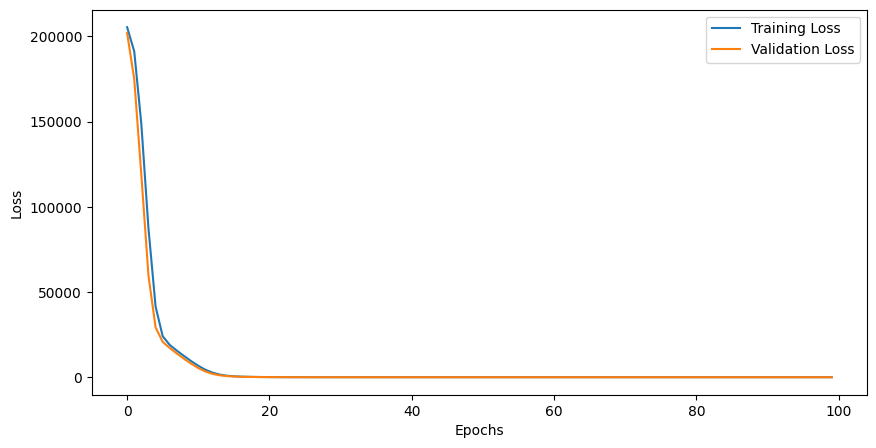

Training MSE: 20.531492675276613
Testing MSE: 18.72161587542606
Training MAE: 3.583519386787903
Testing MAE: 3.440311392183214
R² Score: 0.9345727760032927
      Predicted Values  Actual Values
0           435.001465         433.27
1           436.561127         438.16
2           461.243744         458.42
3           476.055450         480.82
4           435.539612         441.41
...                ...            ...
1909        450.748627         456.70
1910        431.309052         438.04
1911        467.317230         467.80
1912        430.806976         437.14
1913        455.928375         456.78

[1914 rows x 2 columns]


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

powerplant_data = pd.read_csv("https://raw.githubusercontent.com/vishwa-Ansh/DataLoaders/main/powerplant_data.csv")

print(powerplant_data)
print(powerplant_data.shape)
print(powerplant_data.columns)
print(powerplant_data.dtypes)

print(powerplant_data.isnull().sum())

X = powerplant_data.drop("PE", axis=1)
y = powerplant_data["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)


class Artificial_Neural_Network(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train_tensor.shape[1], 6),
            nn.ReLU(),

            nn.Linear(6, 6),
            nn.ReLU(),

            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)


model = Artificial_Neural_Network()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)

    train_losses.append(epoch_train_loss)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:

            outputs = model(xb)

            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)

    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"==> Train Loss = {epoch_train_loss:.4f} "
        f"| Val Loss = {epoch_val_loss:.4f}"
    )

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )


plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()


model.load_state_dict(
    torch.load(
        "best_model.pt",
        weights_only=True
    )
)

model.eval()

with torch.no_grad():

    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)


train_mse = mean_squared_error(
    y_train,
    train_preds.numpy().ravel()
)

test_mse = mean_squared_error(
    y_test,
    test_preds.numpy().ravel()
)

train_mae = mean_absolute_error(
    y_train,
    train_preds.numpy().ravel()
)

test_mae = mean_absolute_error(
    y_test,
    test_preds.numpy().ravel()
)

r2 = r2_score(
    y_test,
    test_preds.numpy().ravel()
)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)

print("Training MAE:", train_mae)
print("Testing MAE:", test_mae)

print("R² Score:", r2)


predicted_df = pd.DataFrame(
    test_preds.numpy().ravel(),
    columns=["Predicted Values"]
)

actual_df = pd.DataFrame(
    y_test.values,
    columns=["Actual Values"]
)

result = pd.concat(
    [predicted_df, actual_df],
    axis=1
)

print(result)